# SPY vs. its constituents — an ETF/basket arbitrage in rcsp

We trade **SPY** against its ~500 constituents. For each constituent *i* with open
price $O_i$ and current mid $P_i$, the cap-weighted **basket index** is

$$\text{idx} = \sum_i w_i\,\frac{P_i}{O_i} = 1 + \sum_i w_i\,r_i$$

(weights sum to 1, so $\text{idx}=1$ at the open and $r_i$ is the return since open).
SPY's **fair value** is $\text{spy\_open}\cdot\text{idx}$, and we trade the edge:

$$\text{edge} = \text{fair} - \text{spy\_mid}\qquad
\begin{cases}\text{edge} > +\text{margin} &\Rightarrow \text{SPY cheap} \Rightarrow \textbf{BUY}\\
\text{edge} < -\text{margin} &\Rightarrow \text{SPY rich} \Rightarrow \textbf{SELL}\end{cases}$$

**The rcsp angle.** There is no N-ary combine and a `@node` has fixed arity, so a
500-name basket is folded the way a real feed handler does it: **one multiplexed
`{symbol, mid}` stream into a single stateful node** that keeps the index in
**O(1) per quote**. SPY rides the same stream as symbol `"SPY"`, so the simulation
and realtime graphs share one node.

> **Data note.** Real S&P 500 *weights* aren't reachable from this sandbox
> (SSGA/slickcharts are blocked), so `sp500_weights.csv` is a modeled snapshot —
> real mega-cap top weights + a cap-weight power-law tail — built from the live
> ticker list. `load_weights(live=True)` re-derives it where the network is open.
> This notebook needs `matplotlib`; it is validated locally (CI covers the module).

In [1]:
%matplotlib inline
import os, sys
# Make basket_arb importable whether the notebook runs from its own dir or repo root.
_here = os.path.abspath("examples/spy_basket") if os.path.isdir("examples/spy_basket") else os.getcwd()
sys.path.insert(0, _here)

import basket_arb as ba
import matplotlib.pyplot as plt

def secs(series):
    "Return (x_seconds_from_start, values) for a run-output series of (datetime, value)."
    t0 = series[0][0]
    return [(t - t0).total_seconds() for t, _ in series], [v for _, v in series]

## 1. Load the S&P 500 weights

In [2]:
weights = ba.load_weights()
print(f"{len(weights)} constituents, weights sum to {sum(weights.values()):.6f}")
print("top 10 by weight:")
for sym, w in sorted(weights.items(), key=lambda kv: -kv[1])[:10]:
    print(f"  {sym:6s} {w*100:5.2f}%")

503 constituents, weights sum to 1.000000
top 10 by weight:
  NVDA    7.30%
  MSFT    6.60%
  AAPL    5.60%
  AMZN    3.90%
  META    2.80%
  AVGO    2.40%
  GOOGL   2.30%
  GOOG    1.90%
  TSLA    1.90%
  BRK-B   1.70%


## 2. Build the multiplexed market-data feed

One stream carries every constituent quote **and** SPY, at a configurable rate
(default **100 quotes/sec/stock**). Because a single edge holds one value per
engine cycle, every quote gets a **distinct microsecond timestamp**. Constituent
prices follow a shared market factor × per-stock beta + idiosyncratic noise; SPY's
mid is the engine's own fair value minus injected **dislocations** (so the strategy
actually trades).

In [3]:
feed = ba.synth_feed(weights, quotes_per_sec_per_stock=100, n_stocks=500, duration=2.0)
print(f"{feed.n_constituent_quotes} constituent + {feed.n_spy_quotes} SPY quotes "
      f"= {feed.n_quotes} total over 2.0s")
print(f"timestamp step = {feed.step_us}µs, decision margin = {feed.margin:.4f} price units")
times = [t for t, _ in feed.rows]
assert times == sorted(times) and len(set(times)) == len(times)  # strictly increasing, distinct
print("timestamps strictly increasing & distinct: OK")

100000 constituent + 100 SPY quotes = 100100 total over 2.0s
timestamp step = 19µs, decision margin = 0.2250 price units
timestamps strictly increasing & distinct: OK


## 3. Run the simulation

In [4]:
res = ba.simulate(feed)
print(f"{res['n_trades']} trades, final mark-to-market PnL = {res['final_pnl']:.2f}")
print(f"engine throughput: {res['n_quotes']} quotes in {res['wall_s']:.3f}s "
      f"= {res['throughput_qps']/1e3:.0f}k quotes/s on a single core")

5 trades, final mark-to-market PnL = -0.75
engine throughput: 100100 quotes in 0.916s = 109k quotes/s on a single core


## 4. What happened — fair value, edge, signals, PnL

`fair`, `edge`, `signal`, `position`, `pnl` are emitted on each SPY tick, so they
share a time axis. SPY's mid is recovered as `fair − edge`.

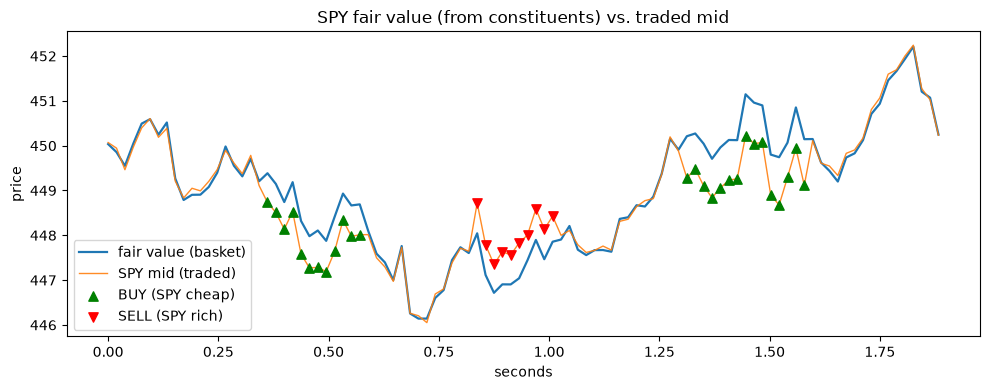

In [5]:
xs, fair = secs(res["fair"])
_, edge = secs(res["edge"])
_, sig = secs(res["signal"])
spy_mid = [f - e for f, e in zip(fair, edge)]

plt.figure(figsize=(10, 4))
plt.plot(xs, fair, lw=1.6, label="fair value (basket)")
plt.plot(xs, spy_mid, lw=1.0, alpha=0.9, label="SPY mid (traded)")
buys = [(x, m) for x, m, g in zip(xs, spy_mid, sig) if g == 1]
sells = [(x, m) for x, m, g in zip(xs, spy_mid, sig) if g == -1]
if buys:  plt.scatter(*zip(*buys),  marker="^", c="green", s=45, zorder=5, label="BUY (SPY cheap)")
if sells: plt.scatter(*zip(*sells), marker="v", c="red",   s=45, zorder=5, label="SELL (SPY rich)")
plt.title("SPY fair value (from constituents) vs. traded mid")
plt.xlabel("seconds"); plt.ylabel("price"); plt.legend(loc="best"); plt.tight_layout()
plt.show()

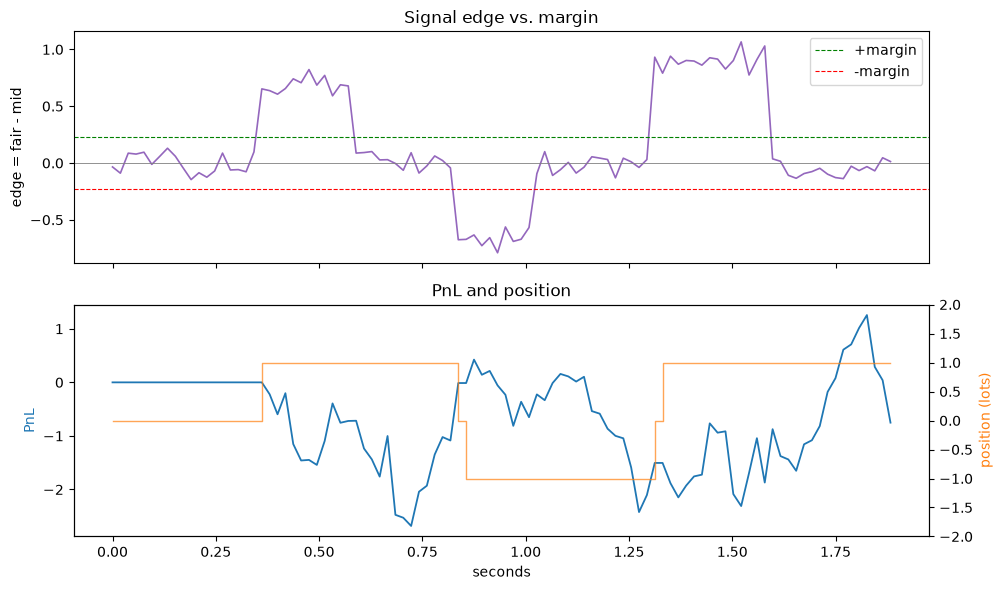

In [6]:
fig, (a1, a2) = plt.subplots(2, 1, figsize=(10, 6), sharex=True)
a1.plot(xs, edge, color="tab:purple", lw=1.2)
a1.axhline(feed.margin, color="green", ls="--", lw=0.8, label="+margin")
a1.axhline(-feed.margin, color="red", ls="--", lw=0.8, label="-margin")
a1.axhline(0, color="grey", lw=0.6)
a1.set_ylabel("edge = fair - mid"); a1.set_title("Signal edge vs. margin"); a1.legend(loc="upper right")

_, pnl = secs(res["pnl"]); _, pos = secs(res["position"])
a2.plot(xs, pnl, color="tab:blue", lw=1.3, label="mark-to-market PnL")
a2.set_ylabel("PnL", color="tab:blue"); a2.set_xlabel("seconds")
a2b = a2.twinx()
a2b.step(xs, pos, where="post", color="tab:orange", lw=1.0, alpha=0.7, label="position")
a2b.set_ylabel("position (lots)", color="tab:orange"); a2b.set_ylim(-2, 2)
a2.set_title("PnL and position")
plt.tight_layout(); plt.show()

## 5. Profiling — per-node cost

The whole point: **one stateful node folds all 500 constituents**, updating the
index in O(1) per quote. The profiler shows `basket_engine` ran once per quote at a
few microseconds each — that's the entire basket, not per-name work.

In [7]:
prof = ba.profile_run(feed)
print(f"{'node':<16}{'count':>10}{'avg µs':>12}{'total ms':>12}")
print("-" * 50)
for name, st in prof["per_node"].items():
    print(f"{name:<16}{st['count']:>10}{st['avg_ns']/1e3:>12.3f}{st['total_ns']/1e6:>12.2f}")
print("-" * 50)
print(f"engine throughput: {prof['throughput_qps']/1e3:.0f}k quotes/s (single core)")

node                 count      avg µs    total ms
--------------------------------------------------
basket_engine       100100       4.371      437.55
curve               100101       3.088      309.12
graph_output           100       0.243        0.02
--------------------------------------------------
engine throughput: 105k quotes/s (single core)


## 6. Latency & throughput on the realtime path

In simulation the engine drains as fast as it can. In **realtime** it reacts to
pushed quotes event-driven. We measure quote→node reaction latency (Python
aggregator on the hot path ⇒ `realtime=True`, not the native GIL-free mode), and
separately the **producer ceiling** — can one Python thread push the feed's
required rate (500 × 100 = 50k quotes/s)?

quote→node reaction: median=104.7µs  p90=144.1µs  p99=176.1µs  (n=240)


python producer ceiling: ~137k ticks/s (engine kept up: True)
feed needs 50k quotes/s  →  one producer suffices


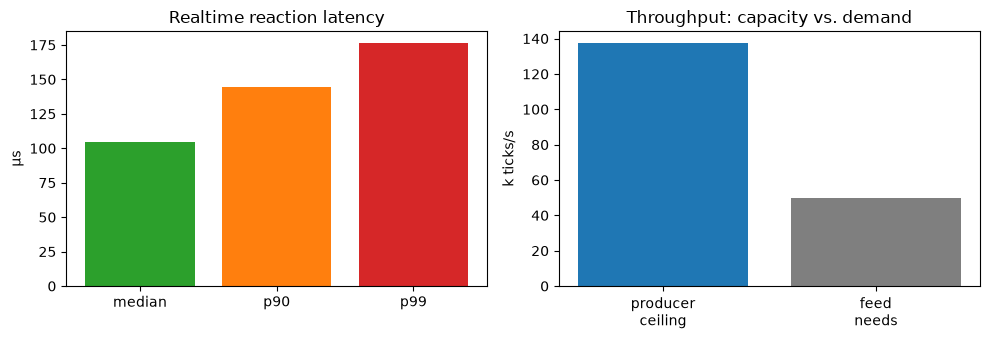

In [8]:
lat = ba.realtime_latency(weights)
print(f"quote→node reaction: median={lat['median_us']:.1f}µs  "
      f"p90={lat['p90_us']:.1f}µs  p99={lat['p99_us']:.1f}µs  (n={lat['n_samples']})")

prod = ba.producer_ceiling(target_rate=50000)
need = 500 * 100
print(f"python producer ceiling: ~{prod['max_rate_per_s']/1e3:.0f}k ticks/s "
      f"(engine kept up: {prod['kept_up']})")
print(f"feed needs {need/1e3:.0f}k quotes/s  →  "
      f"{'one producer suffices' if prod['max_rate_per_s'] > need else 'shard producers / go native'}")

fig, (b1, b2) = plt.subplots(1, 2, figsize=(10, 3.5))
b1.bar(["median", "p90", "p99"], [lat["median_us"], lat["p90_us"], lat["p99_us"]],
       color=["tab:green", "tab:orange", "tab:red"])
b1.set_ylabel("µs"); b1.set_title("Realtime reaction latency")
b2.bar(["producer\nceiling", "feed\nneeds"], [prod["max_rate_per_s"]/1e3, need/1e3],
       color=["tab:blue", "tab:grey"])
b2.set_ylabel("k ticks/s"); b2.set_title("Throughput: capacity vs. demand")
plt.tight_layout(); plt.show()

## Takeaways

- **One graph, one core, the whole basket.** A single stateful node folds all 500
  constituents in O(1) per quote — the profiler shows a few µs/quote and the
  engine sustains ~10⁵ quotes/s on one core.
- **Fair value = weights × return since open**, compared to SPY's traded mid; we
  buy when SPY is cheap to the basket by more than the margin.
- **Realtime reaction** is tens of µs (event-driven), and a single Python producer
  clears the 50k/s the feed needs — above that, shard producers across processes
  (see `examples/e8_multi_symbol_vwap.py`) or use the native GIL-free path for a
  pure-numeric hot loop.
- **Scaling out:** because the basket fold is a single stateful node, you scale by
  sharding the *symbol universe* across processes (one graph each), exactly as the
  VWAP example shows — not one process per symbol.